In [91]:
import numpy as np
import matplotlib.pyplot as plt
import random
np.random.seed(19680801)

from numba import jit
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [92]:
# Utilities for the movie
def update_movie(frame):
    # Clear the previous plot
    ax.clear()
    
    # Plot the current matrix from the sequence
    plt.imshow(System_frames[frame])
    
    plt.title(f'Frame {frame}')
    plt.axis('off')  # Turn off axis labels

In [103]:
@jit(nopython=True)
def autocorrelation(System, SystemSnapshot):
    Ly, Lx = System.shape
    Ly0,Lx0 = SystemSnapshot.shape
    
    if Ly0 != Ly or Lx0 != Lx:
        raise ValueError("Shape of System and SystemSnapshot is not equal")

    DensityParticles = np.sum(System) / size
    
    Sum = 0
    for i in range(Ly):
        for j in range(Lx):
            Sum += System[i][j] * SystemSnapshot[i][j]
    Corr = (Sum / size) - (DensityParticles)**2 # 0.25 is the density of particles^2
    
    return Corr

class Lattice_TASEP():
    
    def __init__(self):
        print("Class initialized")
        
    def reset(self):
        System = np.zeros((Ly, Lx), dtype=int)  # Ly vectors with Lx (zero) components
        return System
        
    def checkboard(self): # Filling the lattice (Lx*Ly) with particles alternatively (chess fashion)    
        System = self.reset()
        
        System[::2, ::2] = 1  # Set even rows and even columns to 1
        System[1::2, 1::2] = 1  # Set odd rows and odd columns to 1

        return System

    def random_system(self, n): # Filling the lattice (Lx*Ly) randomly with n particles
        System = self.reset()

        System = np.concatenate((np.ones(n, int), np.zeros(Lx*Ly-n, int))) #CHECK DIMENSIONs
        np.random.shuffle(System)

        return System.reshape((Ly, Lx))  
    
    def select_action(self, System, X, Y, Along_count, Transv_count): # Action over the (X,Y) lattice site
  
        # TASEP with p=1/2 of jumping foward, p=1/4 of jumping up or down, in total p=1/2
        dice_jump = random.randint(0, 1) 
        if dice_jump == 0:
            JumpAlong = 0
            JumpTransverse = 2 # No jump up or down
        else:
            JumpAlong = 2 # No jump forward
            JumpTransverse = random.randint(0, 1)

        # Update System to the movement 
        System, Along_count, Transv_count = self.update_System(System, X, Y, Along_count, Transv_count, JumpAlong, JumpTransverse)

        return System, Along_count, Transv_count
    
    def select_gaussian_action(self, mu, sigma, System, X, Y, Along_count, Transv_count):
        
        JumpRate = np.random.normal(mu, sigma) # probability of jumping forward or transversally
        dice = random.random() 
        if print_stuff == 2: print("Jump Rate:", JumpRate)

        if dice < JumpRate:
            JumpAlong = 0 
            JumpTransverse = 2 # No jump up or down
            if print_stuff == 2: print("Try to jump along:", dice)

        else:
            JumpAlong = 2 # No jump backwards
            JumpTransverse = random.randint(0, 1) # 0.5 prob of jumping up or down

        # Update System to the movement 
        System, Along_count, Transv_count = self.update_System(System, X, Y, Along_count, Transv_count, JumpAlong, JumpTransverse)

        return System, Along_count, Transv_count

    def update_System(self, System, X, Y, Along_count, Transv_count, JumpAlong, JumpTransverse):
       
        # Simple implementation of Periodic boundary conditions
        xPrev = Ly - 1 if X == 0 else X - 1        
        xNext = 0 if X == Ly - 1 else X + 1
        yNext = 0 if Y == Lx - 1 else Y + 1

        if JumpAlong == 0 and System[X][yNext] == 0:  # hop forward
            temp = System[X][Y]
            System[X][Y] = System[X][yNext]
            System[X][yNext] = temp
            Along_count += 1
            if print_stuff == 2: print("Particle at (%s, %s) hops forward" % (X, Y))


        if JumpTransverse == 0 and System[xPrev][Y] == 0: # hop up
            temp = System[X][Y]
            System[X][Y] = System[xPrev][Y]
            System[xPrev][Y] = temp
            Transv_count += 1
            if print_stuff == 2: print("Particle at (%s, %s) hops up" % (X, Y))


        if JumpTransverse == 1 and System[xNext][Y] == 0:  # hop down
            temp = System[X][Y]
            System[X][Y] = System[xNext][Y]
            System[xNext][Y] = temp
            Transv_count -= 1
            if print_stuff == 2: print("Particle at (%s, %s) hops down" % (X, Y))

        return System, Along_count, Transv_count    
    

In [104]:
# Simulation parameters
runsNumber = 100
totalMCS = 200 #Total number of Monte Carlo steps per single run
Lx = 40 # Number of columns, length
Ly = 20 # Number of rows, height
N = Lx * Ly // 2 # Number of particles
size = Lx * Ly


# Check utilities
print_stuff = 0 #0 do not print; 1 print basics; 2 print details; for unit tests

SystemCheckboard = np.zeros((Ly, Lx), dtype=int)  # Ly vectors with Lx (zero) components 
SystemCheckboard[::2, ::2] = 1  # Set even rows and even columns to 1
SystemCheckboard[1::2, 1::2] = 1  # Set odd rows and odd columns to 1

# Memory allocation                   
DensityParticlesTot = np.zeros(totalMCS) 
CorrTot = np.zeros(totalMCS) 
CurrentAlongTot = np.zeros(totalMCS)  # totalMCS vectors with Ly (zero) components 
CurrentTransvTot = np.zeros(totalMCS)  # totalMCS vectors with Ly (zero) components
OccupationGridTot = np.zeros((Ly, Lx))

Env = Lattice_TASEP()

Class initialized


In [109]:
# Beginning of the simulation
for iwalk in range(runsNumber):

    # Filling the lattice with particles alternatively (chess fashion)    
    #System = Env.checkboard()

    # Filling the lattice with N particles randomly        
    System = Env.random_system(N)

    # Mapping System at t=0
    SystemSnapshot = np.zeros((Ly, Lx), dtype=int)    
    SystemSnapshot = System.copy()
    
    #if print_stuff == 1 or print_stuff == 2:
       # if (SystemSnapshot != SystemCheckboard).all(): raise ValueError("System at t=0, not in checkboard mode")    CORRECT
        
    # Frames for the animation
    System_frames = np.zeros((totalMCS+1, Ly, Lx), dtype=int)
    System_frames[0] = SystemSnapshot
    
    # Memory allocation                   
    Corr = np.zeros(totalMCS)
    DensityParticles = np.zeros(totalMCS) 
    OccupationGrid = np.zeros((Ly, Lx))
    CurrentAlong = np.zeros(totalMCS) 
    CurrentTransv = np.zeros(totalMCS)

    # Beginning of a single run
    for istep in range(totalMCS):
        
        # Computes correlation function; i compute it here and not after to check t=0 case, where CorrFunction[0] = 0.25 by definition 
        Corr[istep] += autocorrelation(System, SystemSnapshot)        
        
        Along_count = 0
        Transv_count = 0       

        for moveAttempt in range(N):
            while True:
                dice = random.randint(0, Lx * Ly - 1)  # Picks the random lattice site in the array
                X = dice // Lx
                Y = dice - X * Lx
                
                """ 
                The lattice is labelled from the left top to the right 
                 as Z= 0, 1, 2    or    [X,Y]= (0,0), (0,1), (0,2) 
                       3, 4, 5                 (1,0), (1,1), (1,2)
                """

                if System[X][Y] == 1: # The lattice is occupied
                    mu = 0.5
                    sigma = 0.3
                    #System, Along_count, Transv_count = Env.select_action(System, X, Y, Along_count, Transv_count)                    
                    System, Along_count, Transv_count = Env.select_gaussian_action(mu, sigma, System, X, Y, Along_count, Transv_count)

                    break  # Exit the loop
                    
        # Computes currents
        CurrentAlong[istep] = Along_count / N # Sum of the current in each lattice in Ly
        CurrentTransv[istep] = Transv_count / N # Sum of the current in each lattice in Lx
                    
        # Computes the total number of particles
        DensityParticles[istep] = np.sum(System) / size
        
        if DensityParticles[istep] != 0.5:
            raise ValueError("The density of particles does not conserve")
    
        # To compute occupation probability
        OccupationGrid += System
        
        # Frames for the movie
        System_frames[istep+1] = System


    # Computing parameters after a single run
    OccupationGrid /= totalMCS
    
    OccupationGridTot += OccupationGrid
    for dt in range(totalMCS):
        CorrTot[dt] += Corr[dt]
        DensityParticlesTot[dt] += DensityParticles[dt] 
        CurrentAlongTot[dt] += CurrentAlong[dt]
        CurrentTransvTot[dt] += CurrentTransv[dt]
    
    if print_stuff == 1 or print_stuff == 2: print("Runs done:", iwalk+1)

    
# Simulation results output
for dt in range(totalMCS):
    CorrTot[dt] /= runsNumber
    DensityParticlesTot[dt] /= (runsNumber)
    CurrentAlongTot[dt] /= (runsNumber)
    CurrentTransvTot[dt] /= (runsNumber)

# Occupation probability of the X axis
OccupationGridTot /= runsNumber
HorizontalOccupProb = OccupationGridTot.sum(axis=0)/Ly

    
print('Finished!')  

Finished!


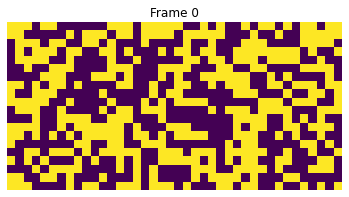

In [110]:
#Movie for the last run. Recommended when MCS is not higher than 200
fig, ax = plt.subplots()

ani = FuncAnimation(fig, update_movie, frames=len(System_frames), repeat=False)

HTML(ani.to_jshtml())

1) total number of particles stays constant at all times


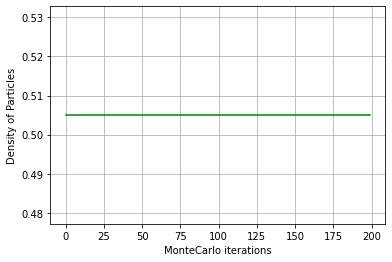

In [111]:
# Testing Area

print('1) total number of particles stays constant at all times')

x_axis=np.array(range(totalMCS))
plt.plot(x_axis, DensityParticlesTot, color='green')
plt.xlabel('MonteCarlo iterations')
plt.ylabel('Density of Particles')
plt.grid(True) 

plt.show()

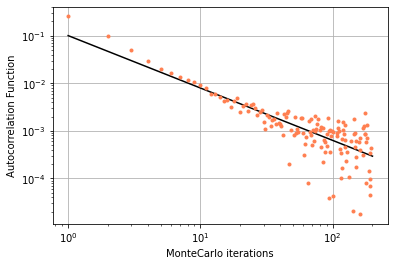

In [112]:
# print('2) Autocorrelation function ~ 1/t')

x_axis=np.array(range(1,totalMCS+1))
f=1/x_axis
f2 = 0.1*x_axis**(-1.1)
plt.plot(x_axis, f2, color='black')
plt.plot(x_axis, CorrTot, '.', color='coral')
plt.xlabel('MonteCarlo iterations')
plt.ylabel('Autocorrelation Function')
plt.xscale('log')
plt.yscale('log')
plt.grid(True) 

plt.show()

3) parallel current ~ rewrite & Perpendicular Current=0


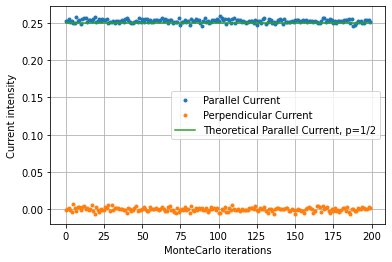

In [113]:
print('3) parallel current ~ rewrite & Perpendicular Current=0')

x_axis=np.array(range(totalMCS))

#The steady current of particle J, through a bond i, i+1 is given by the rate r multiplied by the probability that there is a particle at site i, and site i+1 is vacant
r=1
p=1/2
prob_vac=1/2
f2=np.array([r*p*prob_vac]*totalMCS)

plt.plot(x_axis, CurrentAlongTot, '.', label='Parallel Current')
plt.plot(x_axis, CurrentTransvTot, '.', label='Perpendicular Current')

plt.plot(x_axis,f2, label='Theoretical Parallel Current, p=1/2')

plt.xlabel('MonteCarlo iterations')
plt.ylabel('Current intensity')
plt.legend()
plt.grid(True)

plt.show()

4) Occupation probability


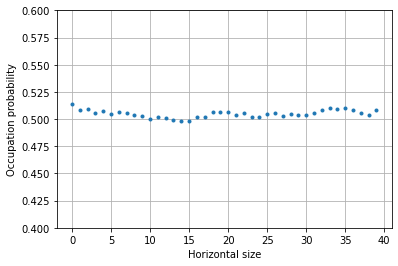

In [114]:
print('4) Occupation probability')

x_axis=np.array(range(Lx))

plt.plot(x_axis, HorizontalOccupProb, '.')

plt.xlabel('Horizontal size')
plt.ylabel('Occupation probability')
plt.ylim([0.4,0.6])
plt.grid(True)

plt.show()